# Online Purchase Intention Prediction

## Data Audit & Exploratory Data Analysis

### Project objective

The objective of this project is to predict whether an online-shopping session will result in a purchase. The target variable is `Revenue`, where `True` represents a purchasing session and `False` represents a non-purchasing session.

### Purpose of this notebook

This notebook prepares and explores the Online Shoppers Purchasing Intention dataset. It checks data quality, identifies potential cleaning requirements and examines patterns that may be relevant for modelling.

The analysis focuses on:

- Missing values and duplicate observations
- Data types and categorical values
- Purchase and non-purchase class balance
- Purchase rate by visitor type
- Purchase behaviour by month
- The potential leakage risk associated with `PageValues`

### Expected outputs

This notebook produces a reviewed dataset, three presentation-ready exploratory charts and documented findings that will guide preprocessing and model development.


In [ ]:
# IMPORTING LIBRARIES AND CREATING THE DATA FRAME

In [14]:
# Import libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Set a fixed seed so results are reproducible
SEED = 1

# Load the dataset from the shared repository
shopping_df = pd.read_csv("../data/raw/online_shoppers_intention.csv")


In [15]:
# Display the first five rows
shopping_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 1. Initial Data Audit

First, we inspect the dataset structure, dimensions, data types and summary statistics.

In [16]:
shopping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [17]:
shopping_df.shape

(12330, 18)

In [18]:
shopping_df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### Duplicate Records

The dataset contains no missing values. We now check for exact duplicate rows before splitting the data. Removing them prevents identical observations from appearing in both the training and test datasets.

In [19]:
# Count exact duplicate rows
duplicate_count = shopping_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 125


In [21]:
# Inspect the duplicate records
duplicate_rows = shopping_df[
    shopping_df.duplicated(keep=False)
].sort_values(by=list(shopping_df.columns))

duplicate_rows.head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


In [22]:
# Show duplicated rows and how many times each combination occurs
duplicate_groups = (
    shopping_df
    .value_counts()
    .reset_index(name="occurrences")
    .query("occurrences > 1")
    .sort_values("occurrences", ascending=False)
)

duplicate_groups.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,occurrences
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False,14
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,2,2,1,3,Returning_Visitor,False,False,7
1,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False,7
3,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,1,1,1,3,Returning_Visitor,False,False,6
4,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,8,13,9,20,Other,False,False,5
5,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,1,1,Returning_Visitor,False,False,4
6,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,2,2,1,1,Returning_Visitor,False,False,4
7,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,1,1,4,3,Returning_Visitor,False,False,4
15,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False,3
21,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,3,3,Returning_Visitor,False,False,3


### Duplicate review

The dataset contains 125 repeated records. Many represent short sessions with little activity and no purchase.

Because the dataset has no unique session identifier, it is not possible to determine whether these records are accidental duplicates or separate sessions with identical behaviour. These records may represent genuine non-purchasing sessions. Therefore, they are retained to avoid removing potentially valid observations.

The possibility that identical records may appear in both the training and test datasets is documented as a limitation.

## 2. Target Definition

The target variable is `Revenue`, which indicates whether a session resulted in a purchase.

- `True`: the visitor completed a purchase
- `False`: the visitor did not complete a purchase

The remaining columns will be used as potential predictor variables.

In [6]:
X = shopping_df.drop("Revenue", axis=1)
y = shopping_df["Revenue"]

In [23]:
# Examine the target distribution
target_distribution = y.value_counts()
target_percentage = y.value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "session_count": target_distribution,
    "percentage": target_percentage
})

target_summary

,session_count,percentage
Revenue,,
False,10422,84.53
True,1908,15.47


### Target balance interpretation

Only approximately 15.5% of sessions resulted in a purchase. The target is therefore imbalanced.

Accuracy alone could be misleading because a model predicting no purchase for every session would already achieve approximately 84.5% accuracy. Evaluation should therefore focus on metrics such as precision, recall and PR-AUC.

## 3. Train-Test Split

The data is divided into training and test sets before preprocessing and modelling.

A stratified split is used to preserve the proportion of purchasing and non-purchasing sessions in both datasets. The test set contains 20% of the observations.

In [25]:
# Create a reproducible stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (9864, 17)
X_test shape: (2466, 17)


In [26]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
Revenue
False    0.845296
True     0.154704
Name: proportion, dtype: float64

Test target distribution:
Revenue
False    0.845093
True     0.154907
Name: proportion, dtype: float64


## 4. Feature Classification

Several variables are stored as numbers but represent categories rather than measurable quantities. These columns are converted to strings so they can be treated as categorical features during preprocessing.

The same conversion must be applied to both the training and test datasets.

In [28]:
cols_to_convert = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

X_train[cols_to_convert] = X_train[cols_to_convert].astype(str)
X_test[cols_to_convert] = X_test[cols_to_convert].astype(str)

In [29]:
numerical_cols = X_train.select_dtypes(include='number').columns
categorical_cols = X_train.select_dtypes(include='object').columns

print(numerical_cols)
print(categorical_cols)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'],
      dtype='object')
Index(['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType',
       'VisitorType'],
      dtype='object')


# 5. Exploratory Data Analysis

This section explores patterns relevant to predicting online purchases. It focuses on:

1. The balance between purchasing and non-purchasing sessions
2. Purchase rate by visitor type
3. Purchase behaviour by month

These findings will support model evaluation and business interpretation.

In [30]:
# Recombine the training features and target for exploratory analysis
eda_df = X_train.copy()
eda_df["Revenue"] = y_train

print("EDA dataset shape:", eda_df.shape)
eda_df.head()

EDA dataset shape: (9864, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
7349,5,74.6,3,43.4,67,1207.653333,0.020833,0.047826,0.0,0.0,Aug,2,2,6,1,Returning_Visitor,False,False
8611,1,4.0,0,0.0,4,67.250000,0.000000,0.013333,0.0,0.0,Dec,2,2,2,2,Returning_Visitor,True,False
3877,0,0.0,0,0.0,12,590.833333,0.010000,0.030000,0.0,0.0,May,1,1,6,4,Returning_Visitor,False,False
2625,5,168.0,0,0.0,31,1239.083333,0.006667,0.020000,0.0,0.0,May,3,2,6,13,Returning_Visitor,False,False
3508,0,0.0,0,0.0,14,1539.000000,0.015385,0.030769,0.0,0.0,May,2,10,2,2,Returning_Visitor,False,False


## 5.1 Class Balance

This chart compares purchasing and non-purchasing sessions. Understanding the target balance is important because a strong imbalance can make accuracy misleading.

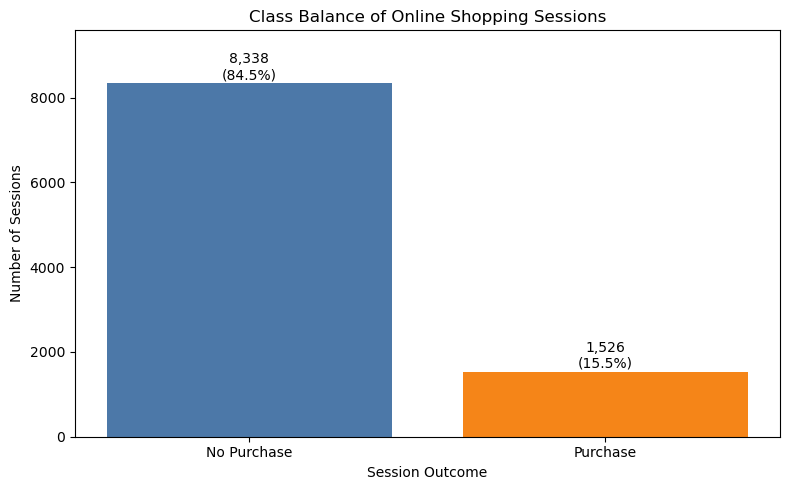

In [31]:
# Calculate class counts and percentages
class_counts = eda_df["Revenue"].value_counts().sort_index()
class_percentages = (
    eda_df["Revenue"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

class_labels = ["No Purchase", "Purchase"]

# Create the chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_labels,
    class_counts.values,
    color=["#4C78A8", "#F58518"]
)

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentages.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center"
    )

plt.title("Class Balance of Online Shopping Sessions")
plt.xlabel("Session Outcome")
plt.ylabel("Number of Sessions")
plt.ylim(0, class_counts.max() * 1.15)
plt.tight_layout()

plt.savefig(
    "../reports/figures/class_balance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Approximately 15.5% of sessions resulted in a purchase while approximately 84.5% did not. The target is therefore imbalanced.

A model that predicts no purchase for every session could achieve approximately 84.5% accuracy while failing to identify any purchasers. PR-AUC, precision and recall should therefore be considered alongside accuracy.

## 5.2 Purchase Rate by Visitor Type

This analysis compares the percentage of sessions resulting in a purchase for new, returning and other visitor types.

In [34]:
# Calculate session counts and purchase rates by visitor type
visitor_summary = (
    eda_df
    .groupby("VisitorType", observed=False)["Revenue"]
    .agg(
        session_count="count",
        purchase_count="sum",
        purchase_rate="mean"
    )
    .reset_index()
)

visitor_summary["purchase_rate_percentage"] = (
    visitor_summary["purchase_rate"] * 100
)

visitor_summary = visitor_summary.sort_values(
    "purchase_rate_percentage",
    ascending=False
)

visitor_summary

,VisitorType,session_count,purchase_count,purchase_rate,purchase_rate_percentage
0,New_Visitor,1339,329,0.245706,24.570575
1,Other,72,12,0.166667,16.666667
2,Returning_Visitor,8453,1185,0.140187,14.018692


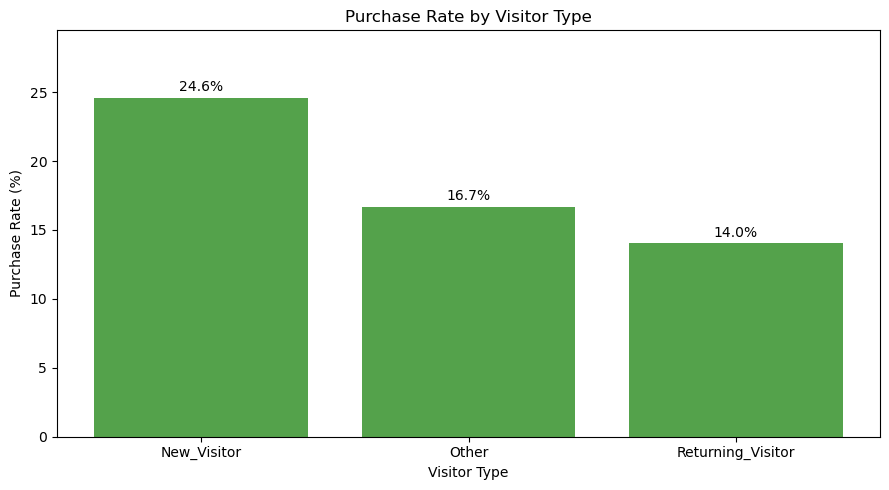

In [37]:
# Create purchase-rate chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    visitor_summary["VisitorType"],
    visitor_summary["purchase_rate_percentage"],
    color="#54A24B"
)

for bar, rate in zip(
    bars,
    visitor_summary["purchase_rate_percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center"
    )

plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.ylim(
    0,
    visitor_summary["purchase_rate_percentage"].max() * 1.2
)
plt.tight_layout()

plt.savefig(
    "../reports/figures/purchase_rate_by_visitor_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()


### Interpretation

New visitors show the highest purchase rate at approximately 25%. Returning visitors represent most sessions but have a lower purchase rate of approximately 14%.

The `Other` category contains relatively few observations. Its purchase rate should therefore be interpreted cautiously.

## 5.3 Purchase Behaviour by Month

This analysis examines whether purchase rates vary throughout the year. The months are placed in calendar order rather than alphabetical order.

In [40]:
# Define the chronological order available in the dataset
month_order = [
    "Feb",
    "Mar",
    "May",
    "June",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec"
]

# Calculate purchase behaviour by month
monthly_summary = (
    eda_df
    .groupby("Month", observed=False)["Revenue"]
    .agg(
        session_count="count",
        purchase_count="sum",
        purchase_rate="mean"
    )
    .reindex(month_order)
    .reset_index()
)

monthly_summary["purchase_rate_percentage"] = (
    monthly_summary["purchase_rate"] * 100
)

monthly_summary

,Month,session_count,purchase_count,purchase_rate,purchase_rate_percentage
0,Feb,134,2,0.014925,1.492537
1,Mar,1539,159,0.103314,10.331384
2,May,2700,286,0.105926,10.592593
3,June,227,24,0.105727,10.572687
4,Jul,351,55,0.156695,15.669516
5,Aug,359,66,0.183844,18.384401
6,Sep,360,70,0.194444,19.444444
7,Oct,443,90,0.203160,20.316027
8,Nov,2372,609,0.256745,25.674536
9,Dec,1379,165,0.119652,11.965192


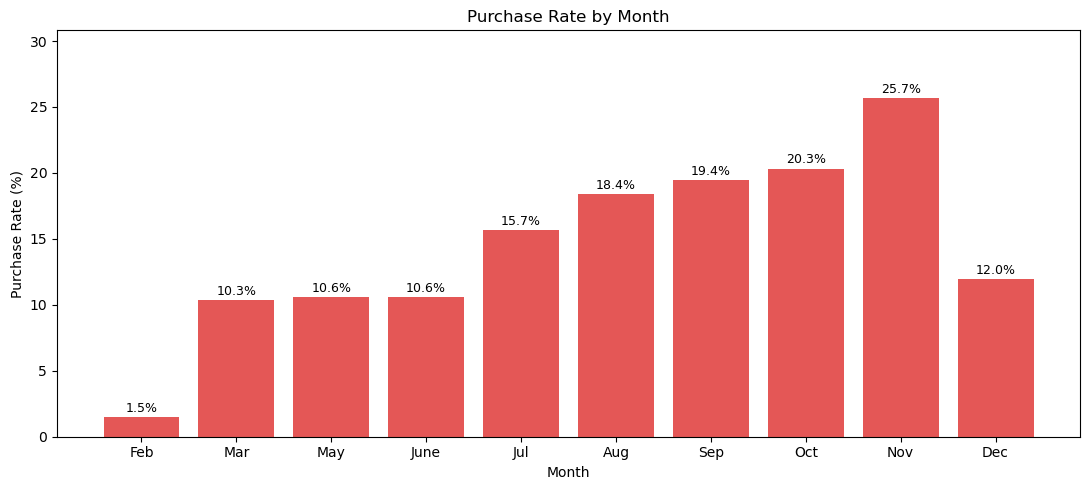

In [41]:
# Create monthly purchase-rate chart
plt.figure(figsize=(11, 5))

bars = plt.bar(
    monthly_summary["Month"],
    monthly_summary["purchase_rate_percentage"],
    color="#E45756"
)

for bar, rate in zip(
    bars,
    monthly_summary["purchase_rate_percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{rate:.1f}%",
        ha="center",
        fontsize=9
    )

plt.title("Purchase Rate by Month")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")
plt.ylim(
    0,
    monthly_summary["purchase_rate_percentage"].max() * 1.2
)
plt.tight_layout()

plt.savefig(
    "../reports/figures/purchase_rate_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Purchase behaviour varies across months. November has the highest purchase rate and February has the lowest.

This may indicate seasonality, including increased purchasing activity around major promotional and holiday periods. However, the dataset does not contain complete data for every month and some months contain relatively few sessions.

# 6. PageValues Leakage Assessment

`PageValues` measures the estimated value of pages visited during a session. It is strongly connected to conversion behaviour and may contain information that becomes available during or after the purchasing journey.

Whether this feature creates leakage depends on when the model is intended to make its prediction. We therefore investigate its relationship with `Revenue` and recommend comparing models with and without this feature.

## 6.1 Assessment Approach

The assessment considers two questions:

1. How strongly is `PageValues` associated with `Revenue`?
2. Would `PageValues` be available when the prediction is made?

Correlation measures association. It does not determine leakage. Leakage depends on whether the feature contains information that would be unavailable at prediction time.

pagevalues_summary

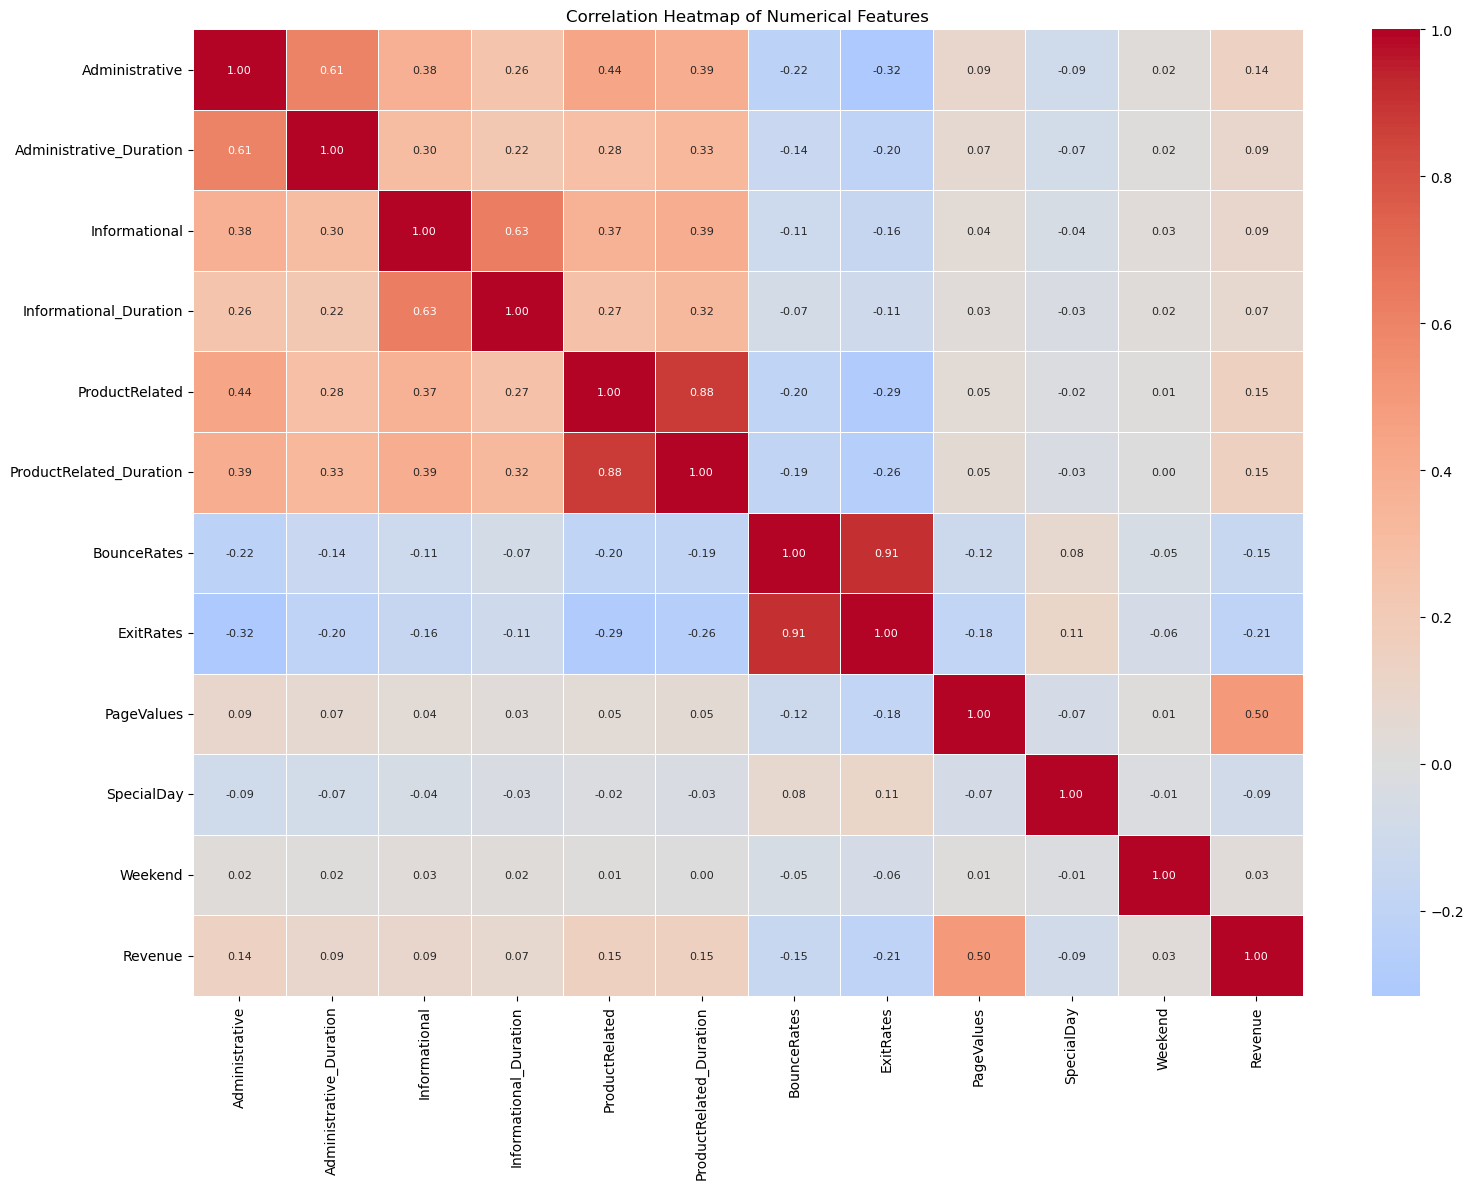

In [57]:
# Select numerical and Boolean variables
correlation_df = eda_df.select_dtypes(
    include=["number", "bool"]
).copy()

# Convert the Boolean target into 0 and 1
correlation_df["Revenue"] = correlation_df["Revenue"].astype(int)

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Create the heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# Display the exact correlation of each numerical feature with Revenue
revenue_correlations = (
    correlation_matrix["Revenue"]
    .drop("Revenue")
    .sort_values(ascending=False)
    .to_frame(name="correlation_with_revenue")
)

revenue_correlations.round(3)

,correlation_with_revenue
PageValues,0.495
ProductRelated,0.153
ProductRelated_Duration,0.151
Administrative,0.139
Administrative_Duration,0.093
Informational,0.090
Informational_Duration,0.071
Weekend,0.030
SpecialDay,-0.086
BounceRates,-0.149


## 6.2 Correlation Interpretation

`PageValues` has the strongest positive correlation with `Revenue` among the numerical variables. Its correlation is approximately 0.49, indicating a moderate positive relationship.

Higher PageValues are therefore associated with a greater likelihood of purchase. Correlation alone does not prove leakage or mean that the feature should be removed.

In [45]:
# Compare PageValues between purchasing and non-purchasing sessions
pagevalues_summary = (
    eda_df
    .groupby("Revenue")["PageValues"]
    .agg(
        session_count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

pagevalues_summary

,session_count,mean,median,minimum,maximum
Revenue,,,,,
False,8338,1.97,0.00,0.0,246.76
True,1526,26.74,16.52,0.0,360.95


## 6.3 Distribution Interpretation

This section examines how frequently PageValues is zero or positive among purchasing and non-purchasing sessions. This helps determine whether positive PageValues occurs only among buyers or also among non-buyers.

In [46]:
# Create groups based on whether PageValues is zero or positive
pagevalues_analysis = eda_df.copy()

pagevalues_analysis["PageValues_group"] = np.where(
    pagevalues_analysis["PageValues"] > 0,
    "Positive PageValues",
    "Zero PageValues"
)

# Calculate the purchase rate for each group
pagevalues_group_summary = (
    pagevalues_analysis
    .groupby("PageValues_group")["Revenue"]
    .agg(
        session_count="count",
        purchase_count="sum",
        purchase_rate="mean"
    )
    .reset_index()
)

pagevalues_group_summary["purchase_rate_percentage"] = (
    pagevalues_group_summary["purchase_rate"] * 100
).round(2)

pagevalues_group_summary

,PageValues_group,session_count,purchase_count,purchase_rate,purchase_rate_percentage
0,Positive PageValues,2183,1227,0.562071,56.21
1,Zero PageValues,7681,299,0.038927,3.89


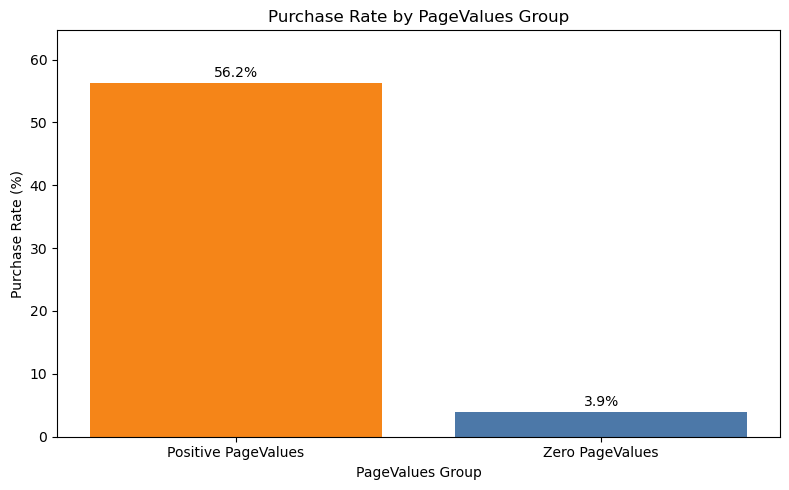

In [47]:
# Plot purchase rates for zero and positive PageValues
plt.figure(figsize=(8, 5))

bars = plt.bar(
    pagevalues_group_summary["PageValues_group"],
    pagevalues_group_summary["purchase_rate_percentage"],
    color=["#F58518", "#4C78A8"]
)

for bar, rate in zip(
    bars,
    pagevalues_group_summary["purchase_rate_percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center"
    )

plt.title("Purchase Rate by PageValues Group")
plt.xlabel("PageValues Group")
plt.ylabel("Purchase Rate (%)")
plt.ylim(
    0,
    pagevalues_group_summary["purchase_rate_percentage"].max() * 1.15
)
plt.tight_layout()

plt.savefig(
    "../reports/figures/pagevalues_purchase_rate.png",
    dpi=300,
    bbox_inches="tight"
)


In [52]:
# Classify PageValues as zero or positive
pagevalues_distribution = eda_df.copy()

pagevalues_distribution["PageValues_status"] = np.where(
    pagevalues_distribution["PageValues"] > 0,
    "Positive",
    "Zero"
)

# Count sessions by Revenue outcome and PageValues status
pagevalues_counts = pd.crosstab(
    pagevalues_distribution["Revenue"],
    pagevalues_distribution["PageValues_status"]
)

pagevalues_counts

PageValues_status,Positive,Zero
Revenue,,
False,956,7382
True,1227,299


In [53]:
# Calculate percentages within each Revenue group
pagevalues_percentages = pd.crosstab(
    pagevalues_distribution["Revenue"],
    pagevalues_distribution["PageValues_status"],
    normalize="index"
).mul(100).round(2)

pagevalues_percentages

PageValues_status,Positive,Zero
Revenue,,
False,11.47,88.53
True,80.41,19.59


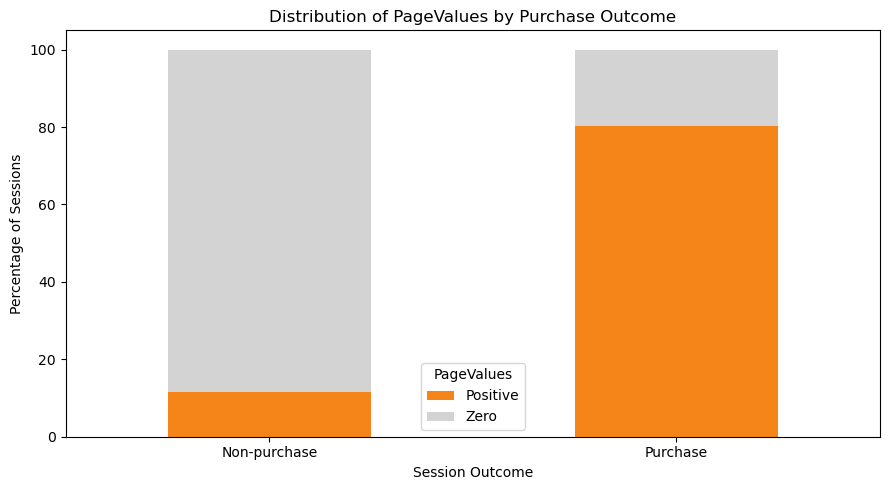

In [54]:
# Create a percentage chart
pagevalues_percentages.index = [
    "Non-purchase",
    "Purchase"
]

pagevalues_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#F58518", "#D3D3D3"]
)

plt.title("Distribution of PageValues by Purchase Outcome")
plt.xlabel("Session Outcome")
plt.ylabel("Percentage of Sessions")
plt.xticks(rotation=0)
plt.legend(
    title="PageValues",
    labels=["Positive", "Zero"]
)
plt.tight_layout()

plt.savefig(
    "../reports/figures/pagevalues_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
# Examine positive PageValues among sessions without a purchase
non_buyer_positive_pagevalues = pagevalues_distribution[
    (pagevalues_distribution["Revenue"] == False) &
    (pagevalues_distribution["PageValues"] > 0)
]

print(
    "Non-buyers with positive PageValues:",
    len(non_buyer_positive_pagevalues)
)

print(
    "Percentage of non-buyers with positive PageValues:",
    round(
        len(non_buyer_positive_pagevalues)
        / (pagevalues_distribution["Revenue"] == False).sum()
        * 100,
        2
    ),
    "%"
)

non_buyer_positive_pagevalues["PageValues"].describe()

Non-buyers with positive PageValues: 956
Percentage of non-buyers with positive PageValues: 11.47 %


count    956.000000
mean      17.171604
std       21.018877
min        0.038035
25%        4.977370
50%       10.546319
75%       21.234237
max      246.758590
Name: PageValues, dtype: float64

### Findings

Positive PageValues occur among both purchasing and non-purchasing sessions. Therefore, PageValues is not a direct copy of the Revenue target.

However, positive PageValues are considerably more common among purchasing sessions. This explains its relatively strong positive correlation with Revenue.

## 6.4 PageValues Conclusion

`PageValues` is not simply a copy of the `Revenue` target because positive values also occur in some non-purchasing sessions. However, positive PageValues are much more common among purchasing sessions and PageValues has the strongest numerical association with Revenue.

The central concern is timing. If the final PageValues value is only available near the end of a session, it may not be available when an early purchase prediction is required.

Therefore, PageValues will be retained as a candidate feature but model performance must be compared:

1. With PageValues
2. Without PageValues

The model without PageValues will represent the more conservative leakage-safe scenario.

# 7. Conclusion and Modelling Handoff

## Key findings

This notebook reviewed the initial data preparation and completed the exploratory data analysis.

The main findings are:

- The dataset contains 12,330 observations and 18 variables.
- No missing values were identified.
- The dataset contains 125 repeated records. These were retained because no unique session identifier is available to determine whether they are invalid duplicates or separate sessions with identical behaviour.
- Approximately 15.5% of sessions resulted in a purchase, confirming that the target variable is imbalanced.
- Purchase rates differ by visitor type.
- Purchase behaviour varies across months, suggesting seasonal patterns.
- `PageValues` has the strongest positive numerical association with `Revenue`.
- Positive PageValues occur among both buyers and non-buyers, so the feature is not a direct copy of the target.
- PageValues remains a potential leakage risk because its availability depends on when the prediction is made.

The three planned presentation-ready EDA charts were created:

1. Class balance
2. Purchase rate by visitor type
3. Purchase rate by month

## Next notebook --> 02_preprocessing_modelling.ipynb

The next notebook will focus on preprocessing, modelling and evaluation. It will include:

1. A reproducible preprocessing pipeline for numerical and categorical features
2. A stratified train-test split
3. A dummy classifier as the minimum-performance baseline
4. An untuned Random Forest baseline
5. An initial XGBoost model with class-imbalance handling
6. Model comparison with and without PageValues
7. Evaluation using PR-AUC, precision, recall, F1-score and a confusion matrix
8. Precision-recall curve visualisation
9. Hyperparameter tuning using Randomized Search followed by a narrower Grid Search
10. Feature-importance analysis and translation of the main predictors into business insights

This separation keeps data understanding and modelling clearly documented while allowing the modelling work to build on the decisions made in this notebook.